# Random Warping Series (RWS)

DTW-based random features ([Wu et al., 2018](https://proceedings.mlr.press/v84/wu18b/wu18b.pdf), Alg. 1): align each sequence against a bank of random warping series and use the soft-DTW distances as features. Normalized to unit norm.

## Environment
Detect the live backend/device and whether a SYCL fast-path is available.

In [1]:
import sys, pathlib
# Make `_nbtools` and the in-repo `ksig` importable whether the notebook is
# launched from ./notebooks or from the repo root (no `pip install` needed).
_nbdir = pathlib.Path.cwd()
_root = _nbdir.parent if (_nbdir / "_nbtools.py").exists() else _nbdir
_nbdir = _root / "notebooks"
for _p in (str(_nbdir), str(_root)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import ksig
import _nbtools as nb
%matplotlib inline

ENV = nb.detect_env()
nb.print_env_banner(ENV)

[2026-06-02 01:18:41,571] [INFO] [real_accelerator.py:260:get_accelerator] Setting ds_accelerator to xpu (auto detect)


icx: warning: -Wl,-z,noexecstack,-z,relro,-z,now,-rpath,$ORIGIN/../..,-rpath,$ORIGIN/../../..: 'linker' input unused [-Wunused-command-line-argument]
icx: warning: -Wl,-z,noexecstack,-z,relro,-z,now,-rpath,$ORIGIN/../..,-rpath,$ORIGIN/../../..: 'linker' input unused [-Wunused-command-line-argument]
/usr/bin/ld: /var/tmp/pbs.8519295.aurora-pbs-0001.hostmgmt.cm.aurora.alcf.anl.gov/claude-35813/tmp99gbctrj/test.o: in function `main':
test.c:(.text+0x25): undefined reference to `io_pgetevents'
icx: error: linker command failed with exit code 1 (use -v to see invocation)


/opt/aurora/25.190.0/frameworks/aurora_frameworks-2025.2.0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-06-02 01:18:46,464] [INFO] [logging.py:107:log_dist] [Rank -1] [TorchCheckpointEngine] Initialized with serialization = False


ksig backend : torch  |  device: xpu  |  SYCL: available  |  ksig unknown


## Deterministic input
`simulate(24, 20, 3, seed=0)` — integrated random walks (the NumPy RNG is identical on every machine).

In [2]:
X = nb.simulate(24, 20, 3, seed=0)
print('X shape:', X.shape, '| dtype:', X.dtype)

X shape: (24, 20, 3) | dtype: float64


## Compute the feature map

**Reference output — NVIDIA H100 NVL (CuPy 14.1.0), kwargs: `n_components=100, stdev=1.0, max_warp=32, normalize=True`:**

```text
gram shape : (24, 24)
diag mean  : 1.0
symmetric  : 0.0
min eig    : 0.000599
```

> ⚠️ **Portability:** RWS is random + DTW-based. The portable invariants are
> `diag == 1`, symmetry (`max|K - Kᵀ| == 0`) and PSD-ness (`min eig ≥ 0` up to
> rounding). Element values differ across backends by RNG stream.

In [3]:
N_COMPONENTS = 100                   # the value the reference was frozen at
k = ksig.kernels.RandomWarpingSeries(n_components=N_COMPONENTS, stdev=1.0, max_warp=32, normalize=True, random_state=0)
k.fit(X)
K = nb.as_host(k(X))
print("gram shape :", tuple(K.shape))
print("diag mean  :", round(float(np.diag(K).mean()), 6))
print("symmetric  :", round(float(np.abs(K - K.T).max()), 8))
print("min eig    :", round(float(np.linalg.eigvalsh((K + K.T) / 2).min()), 6))

gram shape : (24, 24)
diag mean  : 1.0
symmetric  : 0.0
min eig    : 0.001115


## Scaling — green = CUDA reference, blue = this machine

The cell below sweeps **n_samples N  (L=50, d=5, n_components=100)** and times each point on whatever backend
is live, then overlays:

* 🟩 **green** — the frozen reference measured on **NVIDIA H100 NVL** (`cuda_reference.json`),
* 🟦 **blue** — what *this* machine computes now (torch-native on Aurora XPU / CUDA / CPU),
* 🟧 **orange** — the **SYCL** fast-path (this kernel dispatches to `ksig._sycl`),
  drawn **only if** a build is present (`nb.sycl_available()`); the blue curve is
  the same kernel with SYCL forced off, so blue-vs-orange is the head-to-head.

The grid and the knobs at the top of the cell are **tunable** — they default to
the reference grid so blue lines up with green; widen them to push the frontier.

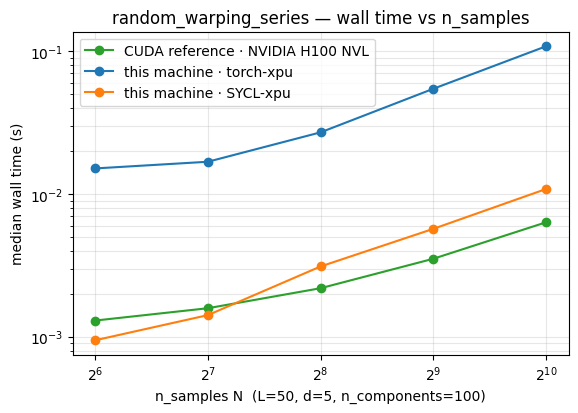

In [4]:
# --- tunable knobs (default to the CUDA-reference grid) ---------------------
N_GRID = [64, 128, 256, 512, 1024]     # sample counts to sweep (feature methods scale ~linearly)
L, D   = 50, 5                  # fixed sequence length / channels
REPS   = 5
N_COMPONENTS = 100                # number of random warping series

def time_one(N):
    Xs = nb.simulate(N, L, D, seed=1)
    k = ksig.kernels.RandomWarpingSeries(n_components=N_COMPONENTS, stdev=1.0, max_warp=32, normalize=True, random_state=0)
    k.fit(Xs)
    return nb.timeit(lambda: k(Xs), reps=REPS, device=ENV["device"])

# BLUE = torch-native baseline: force the SYCL fast-path OFF so this curve is
# the eager wavefront (on XPU, SYCL auto-engages by default, which would make
# blue == orange). A no-op where SYCL is absent.
nb.enable_sycl(False)
times = [time_one(N) for N in N_GRID]

# ORANGE = SYCL fast-path. Drawn ONLY when a SYCL build is available; run the
# same sweep with the fast-path on, then restore the torch-native default.
sycl_times = None
if nb.sycl_available():
    nb.enable_sycl(True)
    sycl_times = [time_one(N) for N in N_GRID]
    nb.enable_sycl(False)

nb.scaling_plot(N_GRID, times, "random_warping_series", sycl_seconds=sycl_times,
                title="random_warping_series — wall time vs n_samples");